# Grid parameters
In this notebook you can investigate at the grid parameters of a classification version.

> **Note:** This notebook needs a classification data set of many postcode areas (sample set, generated and analysed grids, clustering parameters; see the classification documentation and `pylovo-classify`). The stored outputs come from an earlier classification run with an older pylovo version; they were kept when the imports were updated and were not re-created.

In [ ]:
import warnings

import seaborn as sns

from pylovo.classification.database_communication.database_communication import DatabaseCommunication
from pylovo.plotting.generation.networks import get_network_info_for_plotting, plot_grid_on_map

warnings.filterwarnings('ignore')

dc = DatabaseCommunication()
df_parameters_of_grids = dc.municipal_register_with_clustering_parameters_for_classification_version()

Database connection is constructed. 


Make a subselection of the parameters to plot

In [2]:
df_pairplot = df_parameters_of_grids.drop(
    ['version_id', 'plz', 'bcid', 'kcid', 'ratio', 'house_distance_km', 'no_connection_buses', 'resistance',
     'reactance', 'osm_trafo',
     'simultaneous_peak_load_mw',
     'no_household_equ',
     'max_power_mw', 'pop', 'area', 'lat', 'lon', 'ags', 'name_city', 'regio7', 'regio5', 'pop_den',
     'filtered', 'grid_result_id'], axis=1)
df_pairplot.head()

,no_branches,no_house_connections,no_house_connections_per_branch,no_households,no_households_per_branch,max_no_of_households_of_a_branch,transformer_mva,max_trafo_dis,avg_trafo_dis,cable_length_km,cable_len_per_house,vsw_per_branch,max_vsw_of_a_branch
0,18,42,2.333333,242,13.444444,65.0,0.63,0.208748,0.151108,3.344493,0.079631,0.286966,0.539413
1,6,14,2.333333,52,8.666667,25.0,0.25,0.249369,0.122459,0.930422,0.066459,0.224393,0.268053
2,17,50,2.941176,215,12.693395,54.0,0.63,0.295789,0.196393,4.103642,0.082073,0.307144,0.772087
3,24,88,3.666667,214,8.895738,27.0,0.63,0.289717,0.185763,6.034513,0.068574,0.302438,0.514505
4,9,18,2.000000,128,14.222222,40.0,0.40,0.291970,0.192017,2.136543,0.118697,0.331496,0.462934


all selected parameters are plotted with each other

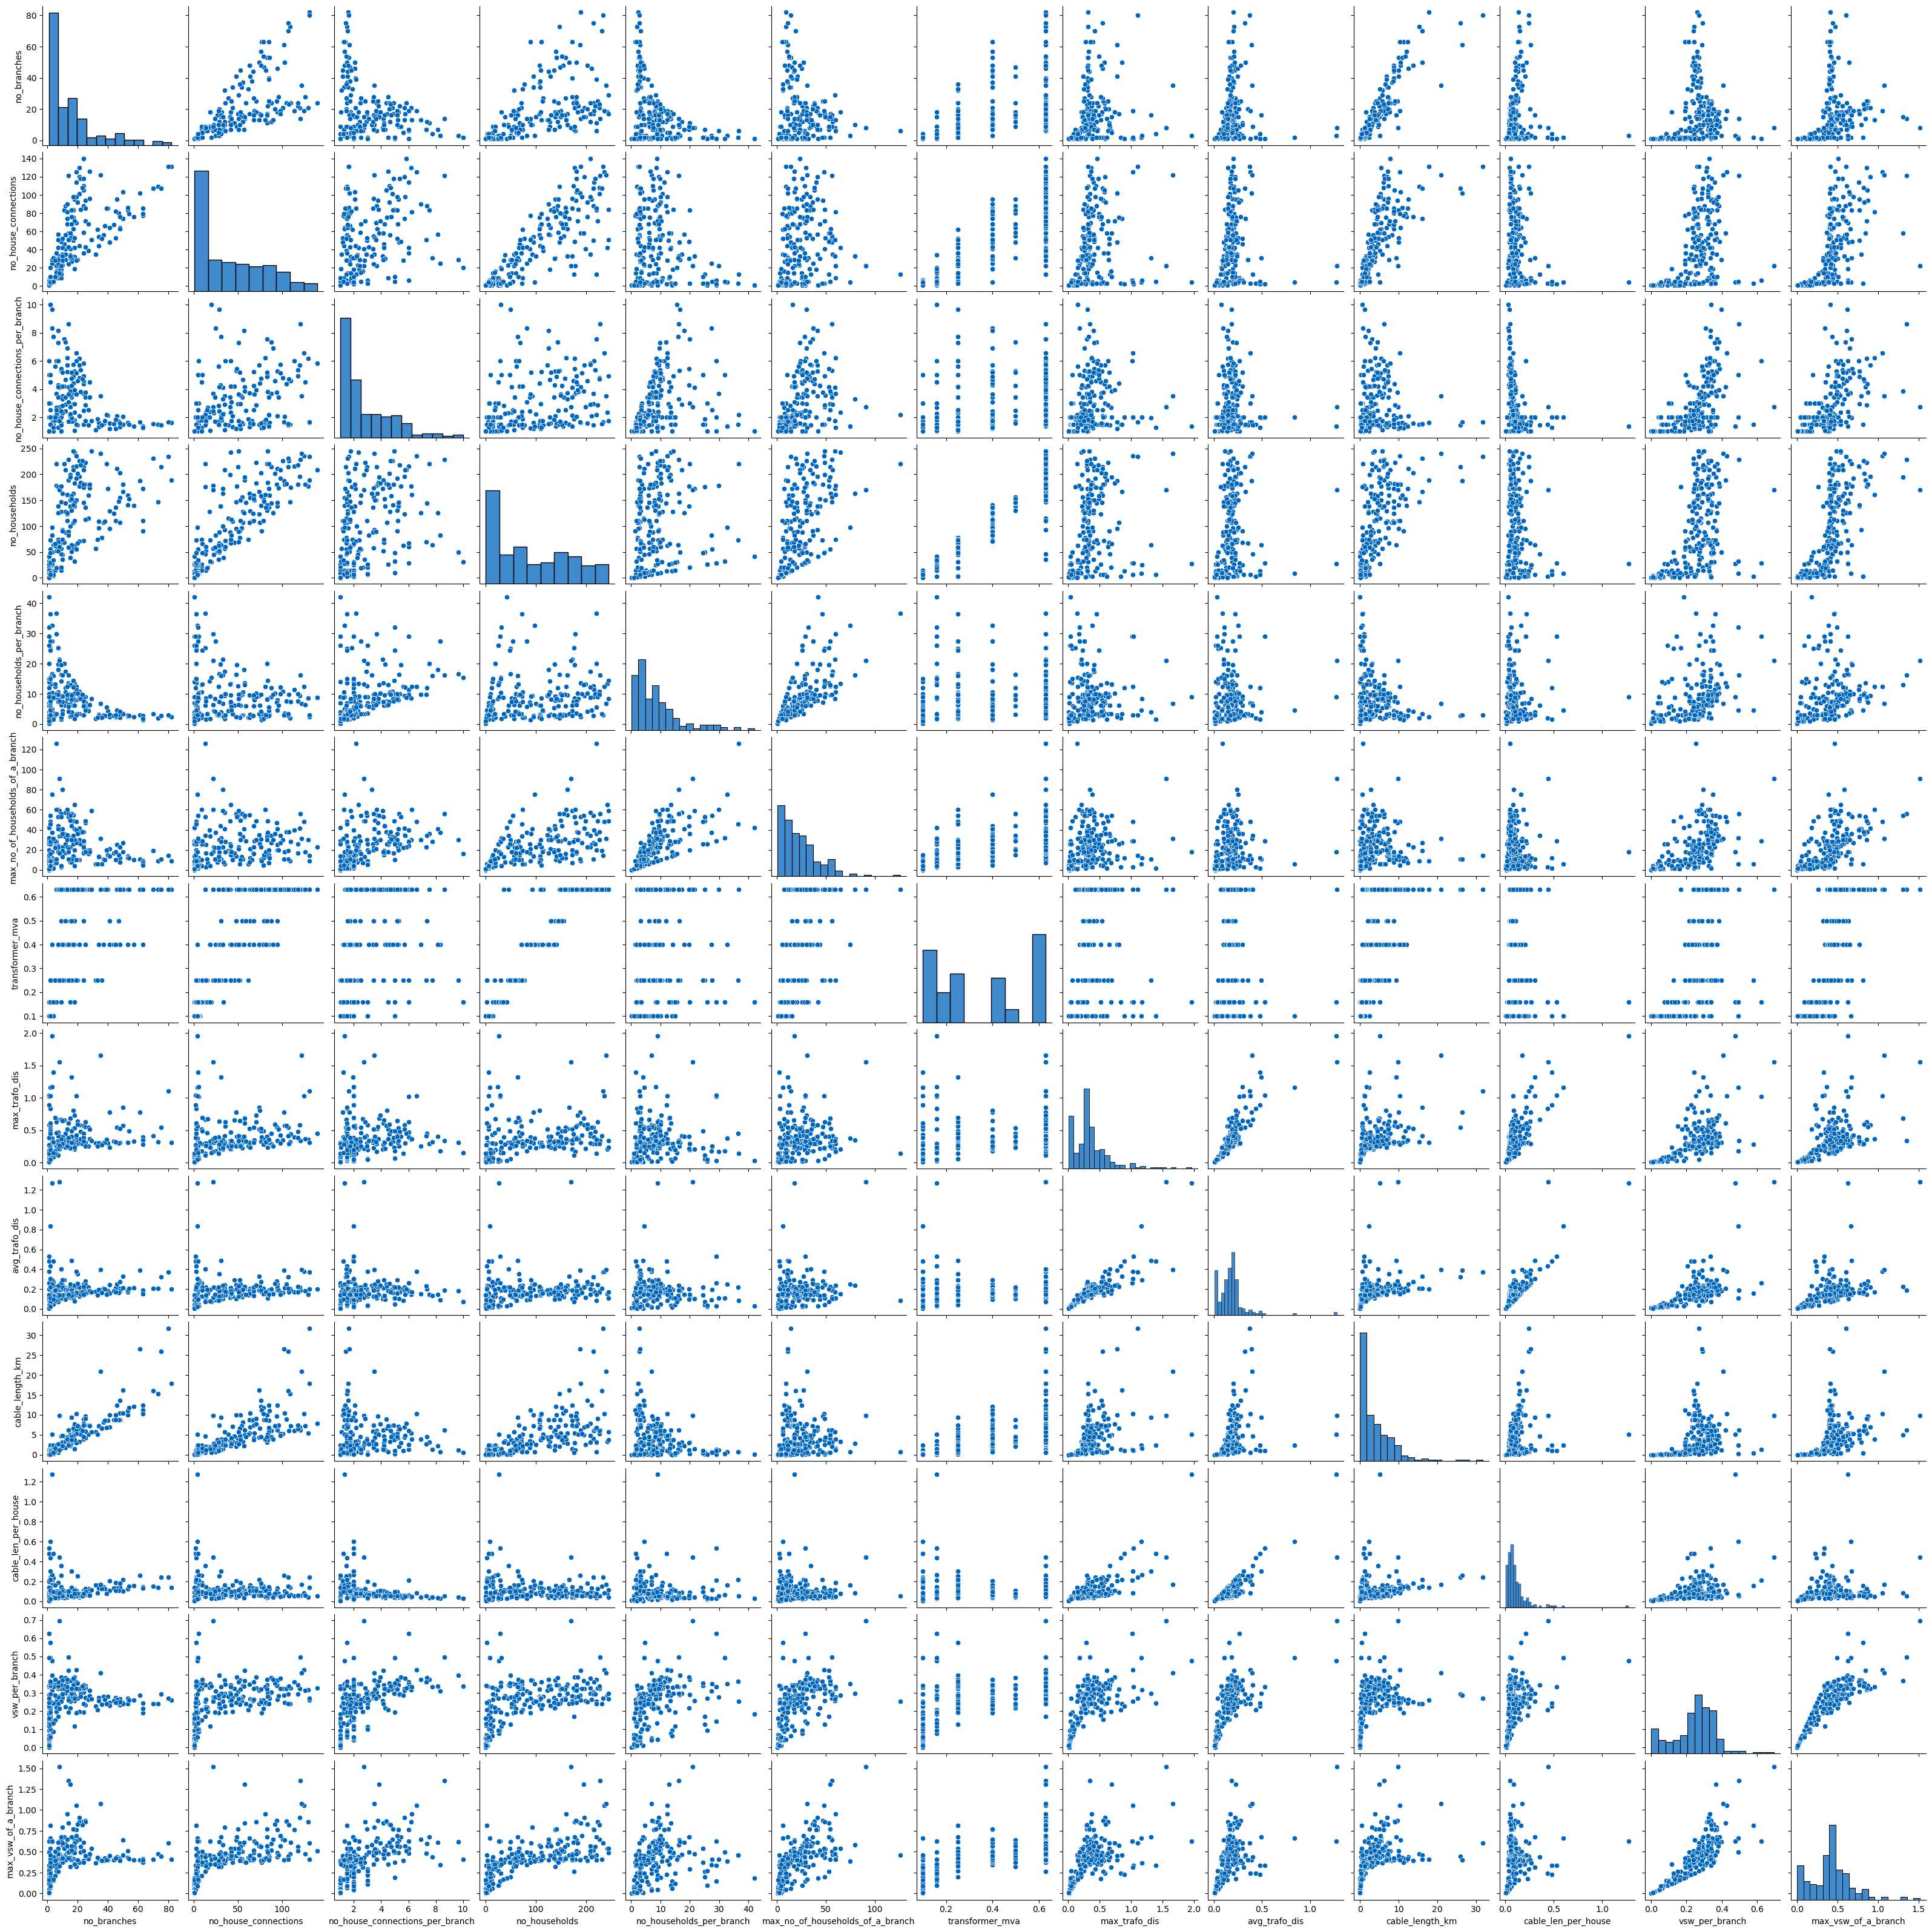

In [3]:
sns.pairplot(df_pairplot)

There is the option to sort the grids by a parameter.

In [4]:
sorted_df = df_parameters_of_grids.sort_values('cable_length_km', ascending=False)
sorted_df.head(10)

,version_id,plz,kcid,bcid,no_connection_buses,no_branches,no_house_connections,no_house_connections_per_branch,no_households,no_household_equ,no_households_per_branch,max_no_of_households_of_a_branch,house_distance_km,transformer_mva,osm_trafo,max_trafo_dis,avg_trafo_dis,cable_length_km,cable_len_per_house,max_power_mw,simultaneous_peak_load_mw,resistance,reactance,ratio,vsw_per_branch,max_vsw_of_a_branch,filtered,pop,area,lat,lon,ags,name,regio7,regio5,pop_den
87,1,89278,1,4,123,80,131,1.637500,234,232.427284,2.905341,14.144703,0.042286,0.63,False,1.103295,0.373407,31.739742,0.242288,6.972819,0.606827,21.649195,6.753179,3.205778,0.270615,0.605013,False,9257,24.244583,48.42212,10.12934,9775134,Nersingen,73,53,381.817250
88,1,89278,2,4,98,61,102,1.672131,188,186.429726,3.056225,11.000000,0.042140,0.63,False,0.779015,0.389314,26.482401,0.259631,5.592892,0.618472,17.486847,6.379595,2.741059,0.286670,0.403146,False,9257,24.244583,48.42212,10.12934,9775134,Nersingen,73,53,381.817250
83,1,89278,1,2,106,75,107,1.426667,214,213.333004,2.844440,11.000000,0.042795,0.63,False,0.546846,0.321298,25.863203,0.241712,6.399990,0.583545,21.949438,5.868663,3.740109,0.292659,0.443642,False,9257,24.244583,48.42212,10.12934,9775134,Nersingen,73,53,381.817250
123,1,63776,2,1,116,35,122,3.485714,240,240.000000,6.857143,31.000000,0.039698,0.63,False,1.658927,0.395051,20.883036,0.171172,7.200000,0.613814,14.293599,10.307328,1.386741,0.408389,1.072971,False,11934,35.866968,50.06625,9.14538,9671143,"Mömbris, Markt",76,54,332.729547
54,1,89278,2,-11,125,82,131,1.597561,189,189.000000,2.304878,9.000000,0.030998,0.63,True,0.313717,0.201901,17.863937,0.136366,5.670000,0.500347,21.306767,3.453216,6.170123,0.259839,0.411824,False,9257,24.244583,48.42212,10.12934,9775134,Nersingen,73,53,381.817250
101,1,89278,1,12,67,50,74,1.480000,166,166.000000,3.320000,27.000000,0.037306,0.63,False,0.853982,0.330576,16.136191,0.218057,4.980000,0.448745,12.044295,4.706457,2.559100,0.240886,0.458735,False,9257,24.244583,48.42212,10.12934,9775134,Nersingen,73,53,381.817250
216,1,87742,1,10,99,70,107,1.528571,231,230.294281,3.289918,19.000000,0.035766,0.63,False,0.414899,0.204501,16.089978,0.150374,6.908828,0.600480,16.692169,3.945857,4.230302,0.238460,0.410429,False,2982,38.174189,47.99492,10.49976,9778113,Apfeltrach,77,55,78.115608
70,1,89278,2,-3,107,73,109,1.493151,147,147.000000,2.013699,9.000000,0.032548,0.63,True,0.314856,0.206772,15.301299,0.140379,4.410000,0.405848,17.637036,2.703558,6.523639,0.241603,0.472316,False,9257,24.244583,48.42212,10.12934,9775134,Nersingen,73,53,381.817250
210,1,87742,1,4,71,48,76,1.583333,203,199.110713,4.148140,23.000000,0.048558,0.63,False,0.523207,0.274836,13.664562,0.179797,5.973321,0.617251,12.031533,3.966484,3.033299,0.250657,0.392945,False,2982,38.174189,47.99492,10.49976,9778113,Apfeltrach,77,55,78.115608
90,1,89278,2,5,88,46,95,2.065217,211,209.207287,4.547985,25.000000,0.036860,0.63,False,0.540995,0.248367,12.422583,0.130764,6.276219,0.572518,12.066870,4.822344,2.502283,0.262323,0.434275,False,9257,24.244583,48.42212,10.12934,9775134,Nersingen,73,53,381.817250


In [5]:
plz, kcid, bcid = get_network_info_for_plotting(sorted_df.iloc[0])
plot_grid_on_map(plz=plz, kcid=kcid, bcid=bcid)

PgReaderWriter is constructed. 
Version: 1 (already exists)
Parameter tables are inserted
PgReaderWriter closed.
PgReaderWriter closed.


Test if geo-data are in lat/long cannot be performed using geopy -> eventual plot errors are possible.
